In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
EPSILON = 1e-8
def savefig(
        figlist,
        log=True, 
        show_scales=True, 
        y_range:list = None, 
        figsize = (6.4, 4.8),
        label:list = None
    ):
    if (y_range == None):
        y_range = [None for _ in figlist]
    if (label == None):
        label = [None for _ in figlist]
    n = len(figlist)
    # peek into instances
    plt.figure(figsize=figsize)
    
    
    for i, f in enumerate(figlist):
        plt.subplot(n, 1, i+1)
        if (type(f) == tuple):
            for g in f:
                plt.plot(g, scalex=show_scales, scaley=show_scales)
            yrange = y_range[i] or [0, len(g)]
            plt.xlim(yrange)
        elif len(f.shape) == 1:
            plt.plot(f, scalex=show_scales, scaley=show_scales)
            yrange = y_range[i] or [0, len(f)]
            
            plt.xlim(yrange)
        elif len(f.shape) == 2:
            if log:
                x = np.log(f + EPSILON)
            else:
                x = f + EPSILON

            dim_range = y_range[i] or (0, x.shape[0], 0, x.shape[1])
            plt.imshow(x.T, origin='lower', interpolation='none', aspect='auto', extent=dim_range, cmap='magma')
            plt.title(label[i])
            
            # if i==1: plt.ylabel("frequency bin (Hz)")
            # if i==2: plt.xlabel("time frame")

        else:
            raise ValueError('Input dimension must < 3.')
        
        if (not show_scales):
            plt.yticks([])
    
    return plt
    # plt.savefig(filename)
    # plt.close()


def drawmanylines(figlist, figsize = (6.4, 4.8), ylim: bool|list = False):
    plt.figure(figsize=figsize)
    for i, f in enumerate(figlist):
        plt.plot(f)
    plt.xlim([0, len(f)])
    if (type(ylim) != bool):
        plt.ylim(ylim)

def drawmanydots(figlist):
    plt.figure()
    for f in figlist:
        plt.plot(f, 'b.')
    plt.xlim([0, len(f)])
    plt.ylim([
        min(np.min(f), 0),
        np.max(f)
    ])

In [3]:
import pyworld as pw
def test_f0(y, f0, t, sr):
    se = pw.cheaptrick(y, f0, t, sr)
    ap = pw.d4c(y, f0, t, sr)

    ysyn = pw.synthesize(f0, se, ap, sr)

    return ysyn

/home/amogus/miniconda3/envs/preprocess/lib/python3.12/site-packages/pyworld/__init__.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
import librosa
import IPython.display

# Tale = 268
# Bat = 101
audio_path = "../Vu/Data/f-03-05-268.wav"
ori_sr = 48000
tgt_sr = 16000
y, sr = librosa.load(audio_path, mono=False, sr=ori_sr)
y = librosa.resample(y, orig_sr=ori_sr, target_sr=tgt_sr)[:,:16000]
ya = np.double(y[0])
yb = np.double(y[1])

IPython.display.Audio(ya, rate=tgt_sr)

<module 'matplotlib.pyplot' from '/home/amogus/miniconda3/envs/preprocess/lib/python3.12/site-packages/matplotlib/pyplot.py'>

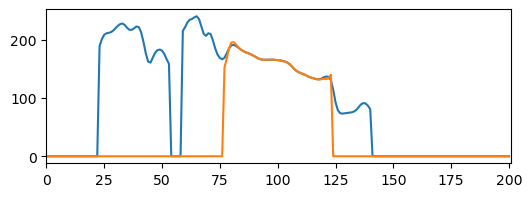

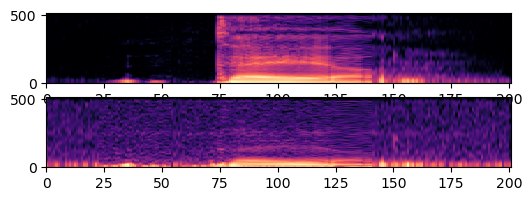

In [25]:
from world.harvest_total import harvest as total_harvest

f0a, t = pw.harvest(ya, tgt_sr)
# f0a = pw.stonemask(ya, f0a, t, tgt_sr)
f0b, t = pw.harvest(yb, tgt_sr)
# f0b = pw.stonemask(yb, f0b, t, tgt_sr)
f0tot = total_harvest(yb, tgt_sr )['f0']
# f0tot = pw.stonemask(yb, f0tot, t, tgt_sr)

sea = pw.cheaptrick(ya, f0a, t, tgt_sr)
apa = pw.d4c(ya, f0a, t, tgt_sr)

seb = pw.cheaptrick(yb, f0a, t, tgt_sr)

figsize = (6, 2)
drawmanylines([f0a, f0b], figsize=figsize)
savefig([sea,seb], figsize=figsize)

In [6]:
yasyn = test_f0(ya, f0a, t, tgt_sr)
IPython.display.Audio(yasyn, rate=tgt_sr)

In [7]:
ytsyn = test_f0(ya, f0b, t, tgt_sr)
IPython.display.Audio(ytsyn, rate=tgt_sr)

# Check F0 candidates

(35, 1001)
(35, 1001)


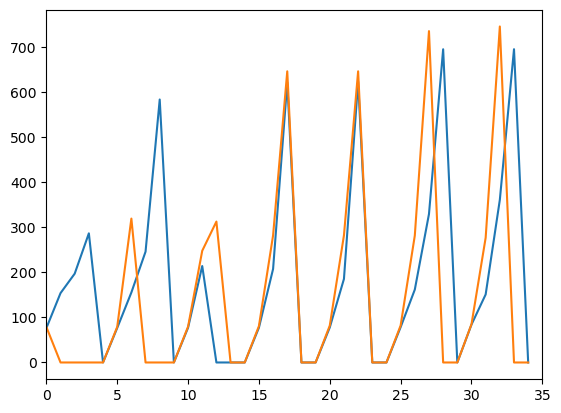

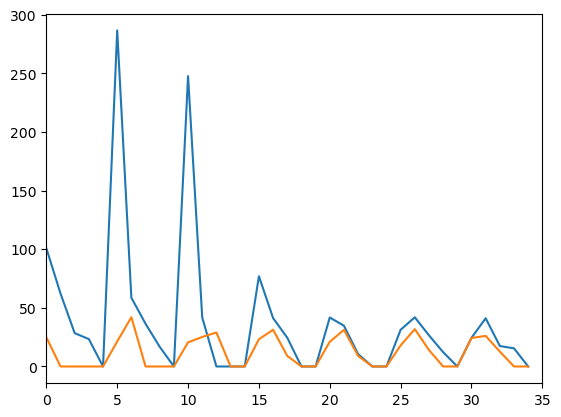

In [47]:
from world.harvest import sawed_harvest
f0_cands, f0_cands_prob = sawed_harvest(ya, tgt_sr)
f0_cands_b, f0_cands_prob_b = sawed_harvest(yb, tgt_sr)

idx_str = 134*5
# snippets = f0_cands[:, idx_str:idx_str+20:5]
# snippets_b = f0_cands_b[:, idx_str:idx_str+20:5]
# probs = f0_cands_prob[:, idx_str:idx_str+20:5]

# drawmanylines(snippets.T)
# drawmanylines(snippets_b.T)
# drawmanylines(probs.T)

a = f0_cands[:, idx_str]
# a = sorted(a)
b = f0_cands_b[:, idx_str]
# b = sorted(b)

drawmanylines([a, b])
drawmanylines([
    f0_cands_prob[:,idx_str],
    f0_cands_prob_b[:, idx_str]
])
print(f0_cands.shape)
print(f0_cands_b.shape)

# Checking step-by-step of Harvest

In [17]:
from world.harvest_total import *

x = ya
fs = tgt_sr
f0_floor: int=71
f0_ceil: int=800
frame_period: int=5

In [18]:
def viz_f0_candidate(f0_cand_list: np.ndarray):
    f0_cand_list = f0_cand_list.T
    f0_nonzero_list = []
    for f0_cand in f0_cand_list:
        f0_cand = f0_cand[f0_cand != 0.]

        if (len(f0_cand) == 0):
            f0_minmax_tuple = [0., 0.]
        else: 
            f0_minmax_tuple = [min(f0_cand), max(f0_cand)]
        f0_nonzero_list.append(f0_minmax_tuple)
    f0_nonzero_list = np.array(f0_nonzero_list)
    drawmanylines([f0_nonzero_list[:,0], f0_nonzero_list[:, 1]], (6,1))
    return f0_nonzero_list

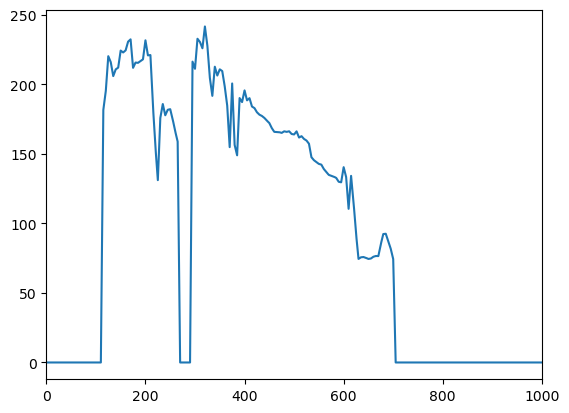

In [19]:
old_f0a_idx = np.arange(len(f0a))
new_f0a_idx = np.linspace(0, len(f0a) - 1, 1001)
new_f0a = np.interp(new_f0a_idx, old_f0a_idx, f0a)
drawmanylines([new_f0a])

(152, 1001)


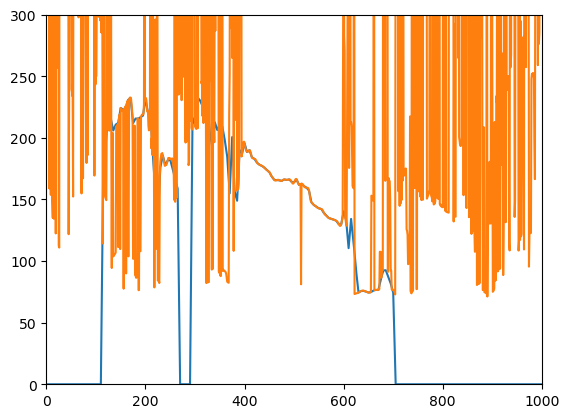

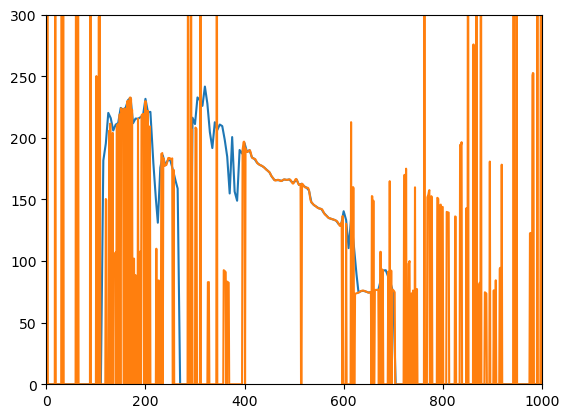

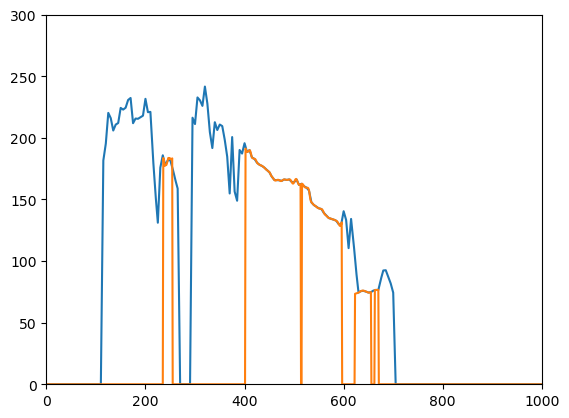

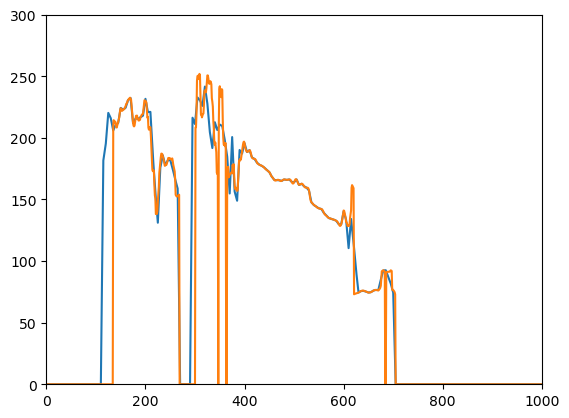

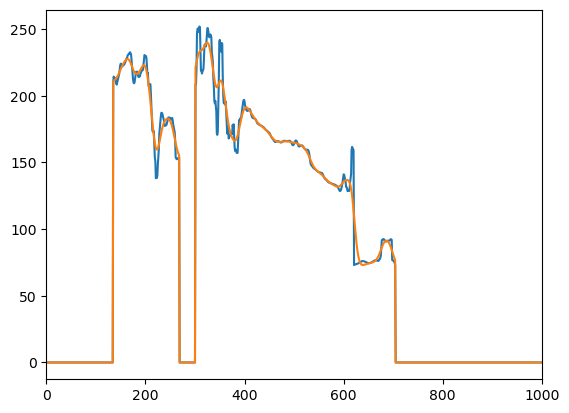

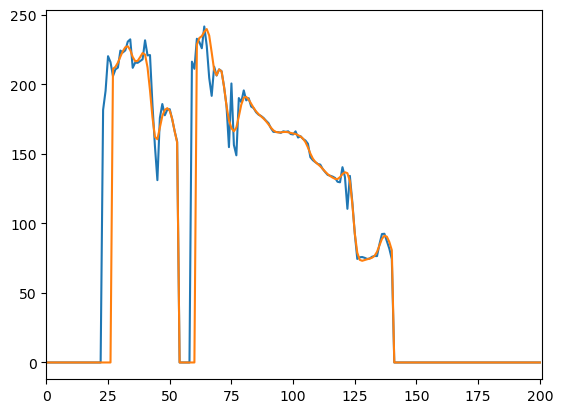

In [24]:


basic_frame_period: int = 1
target_fs = 8000
num_samples = int(1000 * len(x) / fs / basic_frame_period + 1)
basic_temporal_positions = np.arange(0, num_samples) * basic_frame_period / 1000
channels_in_octave = 40
f0_floor_adjusted = f0_floor * 0.9
f0_ceil_adjusted = f0_ceil * 1.1

boundary_f0_list = np.arange(np.ceil(np.log2(f0_ceil_adjusted / f0_floor_adjusted) * channels_in_octave)) + 1
boundary_f0_list = boundary_f0_list / channels_in_octave
boundary_f0_list = 2.0 ** boundary_f0_list
boundary_f0_list *= f0_floor_adjusted

# down - sampling to target_fs Hz
[y, actual_fs] = CalculateDownsampledSignal(x, fs, target_fs)
fft_size = int(2 ** np.ceil(np.log2(len(y) + int(fs / f0_floor_adjusted * 4 + 0.5) + 1)))
y_spectrum = np.fft.fft(y, fft_size)

raw_f0_candidates = CalculateCandidates(len(basic_temporal_positions), boundary_f0_list, len(y),
                                        basic_temporal_positions, actual_fs, y_spectrum, f0_floor, f0_ceil)
print(raw_f0_candidates.shape)
# viz_f0_candidate(raw_f0_candidates)

f0_candidates, number_of_candidates = DetectCandidates(raw_f0_candidates)
# viz_f0_candidate(f0_candidates)
f0_candidates = OverlapF0Candidates(f0_candidates, number_of_candidates)
# viz_f0_candidate(f0_candidates)
f0_candidates, f0_candidates_score = RefineCandidates(y, actual_fs,
                                                        basic_temporal_positions, f0_candidates, f0_floor, f0_ceil)
# viz_f0_candidate(f0_candidates)

f0_candidates, f0_candidates_score = RemoveUnreliableCandidates(f0_candidates, f0_candidates_score)
# viz_f0_candidate(f0_candidates)

# strict_f0, vuv = FixF0Contour(f0_candidates, f0_candidates_score)
# lenient_f0, _ = FixF0Contour(f0_candidates, f0_candidates_score, 1)

# connected_f0 = [s if s>0 else l for s, l in zip(strict_f0, lenient_f0)]

f0_base = SearchF0Base(f0_candidates, f0_candidates_score)
drawmanylines([new_f0a, f0_base, ], ylim=[0,300])
f0_step1 = FixStep1(f0_base, 0.008) # optimized
drawmanylines([new_f0a, f0_step1, ], ylim=[0,300])
f0_step2 = FixStep2(f0_step1, 6) # optimized
drawmanylines([new_f0a, f0_step2, ], ylim=[0,300])
f0_step3 = FixStep3(f0_step2, f0_candidates, 0.18, f0_candidates_score) # optimized
drawmanylines([new_f0a, f0_step3, ], ylim=[0,300])
f0 = FixStep4(f0_step3, 9) # optimized
vuv = copy.deepcopy(f0)
vuv[vuv != 0] = 1
connected_f0, vuv =  f0, vuv


smoothed_f0 = SmoothF0(connected_f0)
drawmanylines([connected_f0, smoothed_f0])
num_samples = int(1000 * len(x) / fs / frame_period + 1)
temporal_positions = np.arange(0, num_samples) * frame_period / 1000
temporal_positions_sampe = np.minimum(len(smoothed_f0) - 1, round_matlab(temporal_positions * 1000))
temporal_positions_sampe = np.array(temporal_positions_sampe, dtype=np.int32)

output =  {
    'temporal_positions': temporal_positions,
    'f0': smoothed_f0[temporal_positions_sampe],
    'vuv': vuv[temporal_positions_sampe]
}

drawmanylines([f0a, output['f0']])